In [3]:
import sys

print(sys.executable)

c:\Users\Aditi\Downloads\Python\CRA\.venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import plotly.express as px 
import sklearn 
import seaborn as sns


In [43]:
case_1 = pd.read_excel("case_study1.xlsx")
case_2 = pd.read_excel("case_study2.xlsx")
description = pd.read_excel("Features_Target_Description.xlsx")
unseen = pd.read_excel("Unseen_Dataset.xlsx")

In [ ]:
# Credit Risk Analysis using CIBIL Data 

## --Business Objective-- 😶‍🌫️🧢

#The objective of this project is to analyze customer credit information, 
# identify factors associated with loan default, 
# and build a predictive model that estimates credit risk.

In [51]:
description.head(60)

,Case_study1 table,Variable Name,Description
0,Internal,Total_TL,Total trade lines/accounts in Bureau
1,NaN,Tot_Closed_TL,Total closed trade lines/accounts
2,NaN,Tot_Active_TL,Total active accounts
3,NaN,Total_TL_opened_L6M,Total accounts opened in last 6 Months
4,NaN,Tot_TL_closed_L6M,Total accounds closes in last 6 months
5,NaN,pct_tl_open_L6M,Percent accounts opened in last 6 months
6,NaN,pct_tl_closed_L6M,percent accounts closed in last 6 months
7,NaN,pct_active_tl,Percent active accounts
8,NaN,pct_closed_tl,Percent closed accounts
9,NaN,Total_TL_opened_L12M,Total accounts opened in last 12 Months


In [ ]:
# Understanding the Dataset

#The available features can be grouped into six broad categories:

# 1. Credit Portfolio
# 2. Credit Behaviour
# 3. Payment Behaviour
# 4. Credit Enquiry Behaviour
# 5. Customer Demographics
# 6. Credit Quality

# This grouping helps us interpret the variables from a business perspective before performing exploratory analysis.

In [6]:
case_1.describe()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25668.500000,4.858598,2.770415,2.088184,0.736754,0.428919,0.184574,0.089095,0.577542,0.422458,...,0.124981,1.136084,1.561847,0.070146,0.282511,2.844904,2.013694,1.089762,-32.575639,-62.149525
std,14819.571046,7.177116,5.941680,2.290774,1.296717,0.989972,0.297414,0.205635,0.379867,0.379867,...,0.505201,2.227997,5.376434,0.340861,0.858168,6.187177,3.198322,2.417496,2791.869609,2790.818622
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,-99999.000000
25%,12834.750000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,4.000000
50%,25668.500000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.556000,0.444000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,33.000000,8.000000
75%,38502.250000,5.000000,3.000000,3.000000,1.000000,1.000000,0.308000,0.053000,1.000000,0.750000,...,0.000000,1.000000,1.000000,0.000000,0.000000,3.000000,2.000000,1.000000,64.000000,17.000000
max,51336.000000,235.000000,216.000000,47.000000,27.000000,19.000000,1.000000,1.000000,1.000000,1.000000,...,27.000000,41.000000,235.000000,10.000000,29.000000,235.000000,55.000000,80.000000,392.000000,392.000000


In [7]:
case_2.describe()

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,Credit_Score
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25668.500000,-8129.961314,-70020.091320,-70022.375838,1.573749,-70003.987085,13.521953,0.184977,0.480053,0.295076,...,-86556.225194,0.167874,0.190414,0.065182,0.170492,0.056302,-45127.943635,0.271116,0.052887,679.859222
std,14819.571046,27749.328514,45823.312757,45819.820741,4.165012,45847.976100,53.336976,0.710240,1.522210,1.027471,...,34111.414750,0.373758,0.376218,0.235706,0.350209,0.213506,49795.784556,0.444540,0.223810,20.502764
min,1.000000,-99999.000000,-99999.000000,-99999.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,469.000000
25%,12834.750000,46.000000,-99999.000000,-99999.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,669.000000
50%,25668.500000,70.000000,-99999.000000,-99999.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333000,0.000000,0.000000,680.000000
75%,38502.250000,161.000000,8.000000,3.000000,1.000000,15.000000,10.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.164250,1.000000,0.000000,691.000000
max,51336.000000,6065.000000,35.000000,35.000000,74.000000,900.000000,900.000000,12.000000,28.000000,20.000000,...,1.708000,1.000000,1.000000,1.000000,1.000000,1.000000,173800.000000,1.000000,1.000000,811.000000


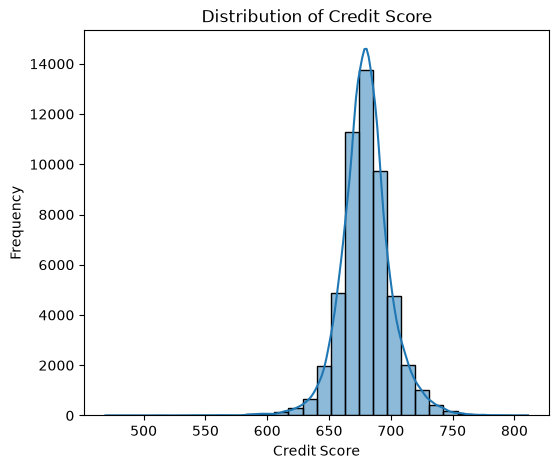

In [ ]:
#Credit Score
plt.figure(figsize=(6,5))
sns.histplot(case_2["Credit_Score"], bins=30, kde=True)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

#Most applicants have an average credit score, while very high and very low scores are relatively uncommon.

#The applicant pool appears to be concentrated around a credit score of approximately 680, 
# indicating that most applicants fall into the medium creditworthiness category.



In [ ]:
# The Credit Score variable follows an approximately normal distribution centered around 680. 
# No obvious anomalies or impossible values were observed, 
# suggesting that the feature is well-behaved and may not require transformation.

In [30]:
case_2["NETMONTHLYINCOME"].sort_values(ascending=False).head(20)

22238    2500000
10851     700000
2673      670000
47484     554640
50508     520000
24353     520000
38128     500000
5213      400000
43550     400000
46114     400000
18184     400000
39125     380000
46654     380000
19344     380000
4913      350000
12791     350000
32441     350000
16283     350000
7833      350000
2008      308568
Name: NETMONTHLYINCOME, dtype: int64

In [31]:
case_1["Total_TL"].nlargest(20)

5261     235
30765    157
29448    143
34173    140
403      129
47323    129
32838    123
15070    122
23570    120
46338    118
3712     115
27759    113
39522    109
11175    108
7732     102
18139    102
20452    102
16792    100
26757    100
37077     98
Name: Total_TL, dtype: int64

In [32]:
case_1["Tot_Missed_Pmnt"].value_counts().head(15)

Tot_Missed_Pmnt
0     34089
1     11390
2      3484
3      1319
4       488
5       243
6       139
7        61
8        43
9        22
11       16
10       15
12        7
13        6
15        4
Name: count, dtype: int64

In [35]:
case_2.dtypes

PROSPECTID                      int64
time_since_recent_payment       int64
time_since_first_deliquency     int64
time_since_recent_deliquency    int64
num_times_delinquent            int64
                                ...  
GL_Flag                         int64
last_prod_enq2                    str
first_prod_enq2                   str
Credit_Score                    int64
Approved_Flag                     str
Length: 62, dtype: object

In [36]:
case_1.dtypes

PROSPECTID                int64
Total_TL                  int64
Tot_Closed_TL             int64
Tot_Active_TL             int64
Total_TL_opened_L6M       int64
Tot_TL_closed_L6M         int64
pct_tl_open_L6M         float64
pct_tl_closed_L6M       float64
pct_active_tl           float64
pct_closed_tl           float64
Total_TL_opened_L12M      int64
Tot_TL_closed_L12M        int64
pct_tl_open_L12M        float64
pct_tl_closed_L12M      float64
Tot_Missed_Pmnt           int64
Auto_TL                   int64
CC_TL                     int64
Consumer_TL               int64
Gold_TL                   int64
Home_TL                   int64
PL_TL                     int64
Secured_TL                int64
Unsecured_TL              int64
Other_TL                  int64
Age_Oldest_TL             int64
Age_Newest_TL             int64
dtype: object

<Axes: xlabel='Approved_Flag', ylabel='count'>

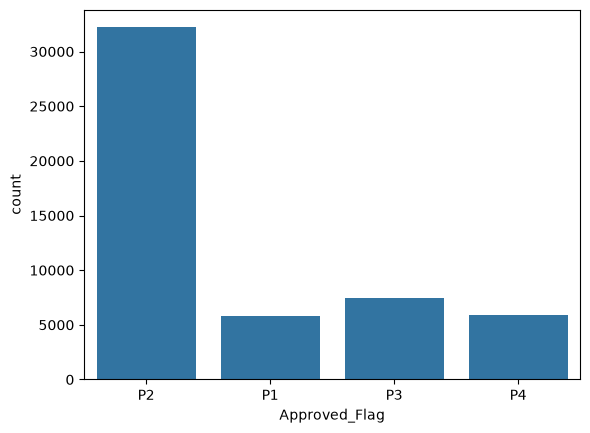

In [37]:
sns.countplot(data=case_2, x="Approved_Flag")

In [45]:
case_2["Approved_Flag"].value_counts()

Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64

In [46]:
case_2["last_prod_enq2"].value_counts()

last_prod_enq2
others          20831
ConsumerLoan    17793
PL               7959
CC               2339
AL               1511
HL                903
Name: count, dtype: int64

In [47]:
case_2["first_prod_enq2"].value_counts()

first_prod_enq2
others          28120
ConsumerLoan    11860
PL               4889
AL               2870
CC               2188
HL               1409
Name: count, dtype: int64

In [48]:
case_2[["CC_Flag","PL_Flag","HL_Flag","GL_Flag"]].sum()

CC_Flag     4593
PL_Flag     8618
HL_Flag    13918
GL_Flag     2715
dtype: int64

In [ ]:
# ✨Key Observations & Initial Inferences✨

# The dataset contains customer credit bureau information used to predict loan approval priority

# Data is split across two tables:

# Case Study 1: Customer account (trade line) information.
# Case Study 2: Credit behaviour, enquiries, demographics and target variable.

# TL = Trade Line = Credit Account
# (Every loan or credit card is considered one trade line.)

# Priority Levels = P1, P2, P3, & P4 (P2 = 32199, P2 represents around 63% of all observations) 
# The dataset is imbalanced, with a majority of applicants falling into the P2 category.

# The Credit Score distribution appears approximately bell-shaped with slight skewness.
# 1) Most customers have scores between 650–700.
# 2) No obvious abnormal values were observed.

# Most numerical variables are right-skewed, including:-
# 1) Total_TL
# 2) Tot_Missed_Pmnt
# 3) NETMONTHLYINCOME
# 4) num_times_delinquent
# A small number of customers naturally have many accounts, high income or repeated delinquencies. 
# Log transformations may be considered for these variables to reduce skewness.
    
# Initial Business Interpretation

# Potential indicators of higher credit risk include:

# 1) Higher number of missed payments.
# 2) More delinquencies.
# 3) Lower credit score.
# 4) Larger number of unsecured accounts.
# 5) Frequent recent credit enquiries.

# # These hypotheses will be explored further during Exploratory Data Analysis.

In [52]:
case_1.shape, case_2.shape

((51336, 26), (51336, 62))